In [1]:
from pathlib import Path

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/wind_scraping_sep_2026.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [5]:
results = pd.read_csv(results_fp)

In [6]:
results["Score"] = results.Score.map(
    {
        10675893: "Correct (DNE)",
        7592334: "Correct (Exists)",
        14791492: "Intern value wrong, LLM correct",
        13463000: "Intern value wrong, LLM wrong also",
        931198: "Value does not exist but LLM reported it",
        3305961: "Value exists but LLM did not find",
        238: "Value exists but LLM got it wrong",
        49407: "Bad web scrape",
    }
)
results["Score"].value_counts()

Score
Correct (DNE)                         41
Correct (Exists)                      34
Value exists but LLM did not find      9
Intern value wrong, LLM correct        7
Bad web scrape                         4
Value exists but LLM got it wrong      4
Intern value wrong, LLM wrong also     1
Name: count, dtype: int64

In [9]:
exist_cats = {
    "Correct (Exists)",
    "Intern value wrong, LLM correct",
    "Intern value wrong, LLM wrong also",
    "Value exists but LLM did not find",
    "Value exists but LLM got it wrong",
}

results["ordinance_exists"] = (
    results["Score"].apply(
        lambda x: int(x in exist_cats)
    )
)

results["ordinance_exists"].value_counts()

ordinance_exists
1    55
0    45
Name: count, dtype: int64

In [13]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        # "Intern value wrong, LLM correct"
    },
    "exists_report": {
        "Correct (Exists)",
        "Intern value wrong, LLM correct",
    },
    "dne_report": {
        "Value does not exist but LLM reported it",
        "Bad web scrape",
    },
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

truth_labels_col = "ordinance_exists"

out = compute_stats(
    results,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[41 14]
 [ 4 41]]
accuracy=82.00%, precision=82.00%, recall=74.55%, F1=78.10%


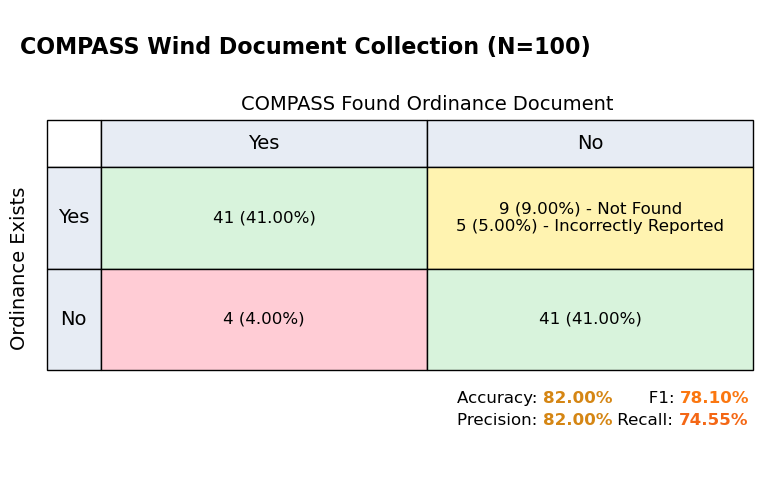

In [15]:
plot_compass_confusion_matrix_from_data(
    results,
    score_cats,
    title="COMPASS Wind Document Collection",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Found Ordinance Document",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "wind_web_scraping_sep_2025.png",
    color_scores=True,
)